In [16]:
# General purpose
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Signal processing / IO
from scipy.io import loadmat

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set()

## Constants

In [17]:
FILEPATH_MAT = "data/S1_E1_A1.mat"
FS = 2000

# Inputs: EMG channels corresponding to thumb/index/middle/ring/pinky (0-based)
EMG_CHANNELS_0BASED = [3, 6, 8, 11, 14]
FINGER_NAMES = ["thumb", "index", "middle", "ring", "pinky"]

# Targets: glove joint angles 3, 6, 8, 11, 14 (1-based in the hand picture)
GLOVE_JOINTS_1BASED = [3, 6, 8, 11, 14]

TRAIN_PCT = 0.6
VAL_PCT = 0.2
TEST_PCT = 0.2
CV_K = round((TRAIN_PCT + VAL_PCT) / VAL_PCT)  # 4 for 60/20/20
assert abs(TRAIN_PCT + VAL_PCT + TEST_PCT - 1.0) < 1e-12

## Load Data + Select Channels/Targets

In [18]:
data = loadmat(FILEPATH_MAT)
print("Dataset variables:")
print([key for key in data.keys() if not key.startswith("__")])

emg = data["emg"]
glove = data["glove"]
stimulus = data["restimulus"]
repetition = data["rerepetition"]

# time alignment
assert emg.shape[0] == glove.shape[0] == stimulus.shape[0] == repetition.shape[0]

stimulus_1d = stimulus.squeeze().astype(int)
repetition_1d = repetition.squeeze().astype(int)

N_STIMULI = len(np.unique(stimulus_1d)) - 1  # -1 because 0 is resting condition
N_REPETITIONS = len(np.unique(repetition_1d)) - 1  # -1 because 0 is not a repetition

# Ensure glove is 2D: (n_samples, n_glove_dims)
glove_2d = glove
if glove_2d.ndim == 1:
    glove_2d = glove_2d.reshape(-1, 1)
elif glove_2d.ndim > 2:
    glove_2d = glove_2d.reshape(glove_2d.shape[0], -1)

# Select glove targets
joint_idx = [j - 1 for j in GLOVE_JOINTS_1BASED]
assert max(joint_idx) < glove_2d.shape[1], "Selected glove indices exceed available glove dimensions."
glove_sel = glove_2d[:, joint_idx]
joint_names = [f"angle{j}" for j in GLOVE_JOINTS_1BASED]

# Select EMG channels
assert len(EMG_CHANNELS_0BASED) == len(FINGER_NAMES)
assert max(EMG_CHANNELS_0BASED) < emg.shape[1], "Selected EMG channel index exceeds available channels."
emg_sel = emg[:, EMG_CHANNELS_0BASED]
channel_labels = FINGER_NAMES

n_samples, n_channels = emg_sel.shape
print(f"EMG selected shape: {emg_sel.shape}")
print(f"Glove selected shape: {glove_sel.shape}")
print(f"Stimuli: {N_STIMULI} | Repetitions: {N_REPETITIONS}")

Dataset variables:
['subject', 'exercise', 'emg', 'acc', 'gyro', 'mag', 'glove', 'stimulus', 'repetition', 'restimulus', 'rerepetition']
EMG selected shape: (2292526, 5)
Glove selected shape: (2292526, 5)
Stimuli: 9 | Repetitions: 10


## Trial-wise Feature Extraction

In [19]:
eps = 1e-12

def _tkeo_mean(x: np.ndarray) -> float:
    # Teager–Kaiser energy operator: ψ[x[n]] = x[n]^2 - x[n-1]x[n+1]
    if x.size < 3:
        return 0.0
    return float(np.mean(x[1:-1] ** 2 - x[:-2] * x[2:]))

def _hoyer_sparsity(x: np.ndarray, eps: float = 1e-12) -> float:
    # Hoyer sparsity in [0, 1]. We use abs(.) for EMG.
    v = np.abs(x).astype(float)
    n = v.size
    if n == 0:
        return 0.0
    l1 = np.sum(v)
    l2 = np.linalg.norm(v)
    if l2 < eps:
        return 0.0
    return float((np.sqrt(n) - (l1 / (l2 + eps))) / (np.sqrt(n) - 1.0 + eps))

def _irregularity_factor(x: np.ndarray, eps: float = 1e-12) -> float:
    # Time-domain irregularity: energy of first difference relative to signal energy
    if x.size < 2:
        return 0.0
    num = np.mean(np.diff(x) ** 2)
    den = np.mean(x ** 2)
    return float(np.sqrt((num + eps) / (den + eps)))

def _waveform_length_ratio(x: np.ndarray, eps: float = 1e-12) -> float:
    # Normalized waveform length: WL / sum(|x|)
    if x.size < 2:
        return 0.0
    wl = np.sum(np.abs(np.diff(x)))
    amp = np.sum(np.abs(x))
    return float(wl / (amp + eps))

FEATURE_FUNCS = {
    "mean": lambda x: float(np.mean(x)),
    "std": lambda x: float(np.std(x, ddof=0)),
    "max_amp": lambda x: float(np.max(np.abs(x))),
    "tkeo": _tkeo_mean,
    "sparsity": _hoyer_sparsity,
    "irregularity": _irregularity_factor,
    "wl_ratio": _waveform_length_ratio,
}

def extract_features_one_trial(trial_emg: np.ndarray) -> np.ndarray:
    """
    trial_emg: shape (n_samples_in_trial, n_channels)
    returns: shape (n_channels * n_features,)
    """
    feats: list[float] = []
    for ch in range(trial_emg.shape[1]):
        x = trial_emg[:, ch].astype(float)
        for name in FEATURE_FUNCS:
            feats.append(FEATURE_FUNCS[name](x))
    return np.asarray(feats, dtype=float)

# Build trial-level dataset (one row per (stimulus, repetition) pair)
unique_stimuli = np.unique(stimulus_1d)
unique_stimuli = unique_stimuli[unique_stimuli > 0]  # ignore rest (0)
unique_reps = np.unique(repetition_1d)
unique_reps = unique_reps[unique_reps > 0]

X_list: list[np.ndarray] = []
Y_list: list[np.ndarray] = []
labels_list: list[int] = []
meta_list: list[tuple[int, int, int, int, int]] = []  # (start, end, stim, rep, length_samples)

for stim_i in unique_stimuli:
    for rep_i in unique_reps:
        mask = (stimulus_1d == int(stim_i)) & (repetition_1d == int(rep_i))
        if not np.any(mask):
            continue

        idx = np.flatnonzero(mask)
        start = int(idx[0])
        end = int(idx[-1] + 1)
        length = int(idx.size)

        trial_emg = emg_sel[mask, :]
        trial_glove = glove_sel[mask, :]

        X_list.append(extract_features_one_trial(trial_emg))
        Y_list.append(np.mean(trial_glove, axis=0))
        labels_list.append(int(stim_i))
        meta_list.append((start, end, int(stim_i), int(rep_i), length))

X = np.vstack(X_list) if X_list else np.empty((0, n_channels * len(FEATURE_FUNCS)))
Y = np.vstack(Y_list) if Y_list else np.empty((0, glove_sel.shape[1]))
labels = np.asarray(labels_list, dtype=int) if labels_list else np.empty((0,), dtype=int)
meta = np.asarray(meta_list, dtype=int) if meta_list else np.empty((0, 5), dtype=int)

print(f"Trials kept: {X.shape[0]} | Features/trial: {X.shape[1]} | Targets/trial: {Y.shape[1]}")
if meta.size:
    lengths = meta[:, 4]
    print(f"Trial length (samples): min={lengths.min()} | median={int(np.median(lengths))} | max={lengths.max()}")

# Feature names: n_features per selected channel
feature_names: list[str] = []
for ch in range(n_channels):
    for feat_name in FEATURE_FUNCS:
        feature_names.append(f"{feat_name}_{channel_labels[ch]}")

df_features = pd.DataFrame(X, columns=feature_names)

# Drop any trials with non-finite values (safety)
finite_mask = np.isfinite(df_features.values).all(axis=1) & np.isfinite(Y).all(axis=1)
df_features = df_features.loc[finite_mask].reset_index(drop=True)
Y = Y[finite_mask]
labels = labels[finite_mask]
meta = meta[finite_mask]

print(f"Usable trials after finite-check: {df_features.shape[0]}")

Trials kept: 90 | Features/trial: 35 | Targets/trial: 5
Trial length (samples): min=5667 | median=11518 | max=20935
Usable trials after finite-check: 90


## Train/Val/Test Split

In [20]:
X_trainval, X_test, Y_trainval, Y_test, labels_trainval, labels_test, meta_trainval, meta_test = train_test_split(
    df_features.values,
    Y,
    labels,
    meta,
    test_size=TEST_PCT,
    random_state=RANDOM_STATE,
    stratify=labels,
 )

X_train, X_val, Y_train, Y_val, labels_train, labels_val, meta_train, meta_val = train_test_split(
    X_trainval,
    Y_trainval,
    labels_trainval,
    meta_trainval,
    test_size=VAL_PCT / (TRAIN_PCT + VAL_PCT),
    random_state=RANDOM_STATE,
    stratify=labels_trainval,
 )

print(f"Train set size: {X_train.shape[0]} trials")
print(f"Validation set size: {X_val.shape[0]} trials")
print(f"Test set size: {X_test.shape[0]} trials")

# CV folds over TrainVal: stratified by stimulus label
skf = StratifiedKFold(n_splits=CV_K, shuffle=True, random_state=RANDOM_STATE)
folds = [val_idx for _, val_idx in skf.split(X_trainval, labels_trainval)]
print("CV fold sizes (TrainVal):", [len(f) for f in folds])

Train set size: 54 trials
Validation set size: 18 trials
Test set size: 18 trials
CV fold sizes (TrainVal): [18, 18, 18, 18]


## Correlation (TrainVal)

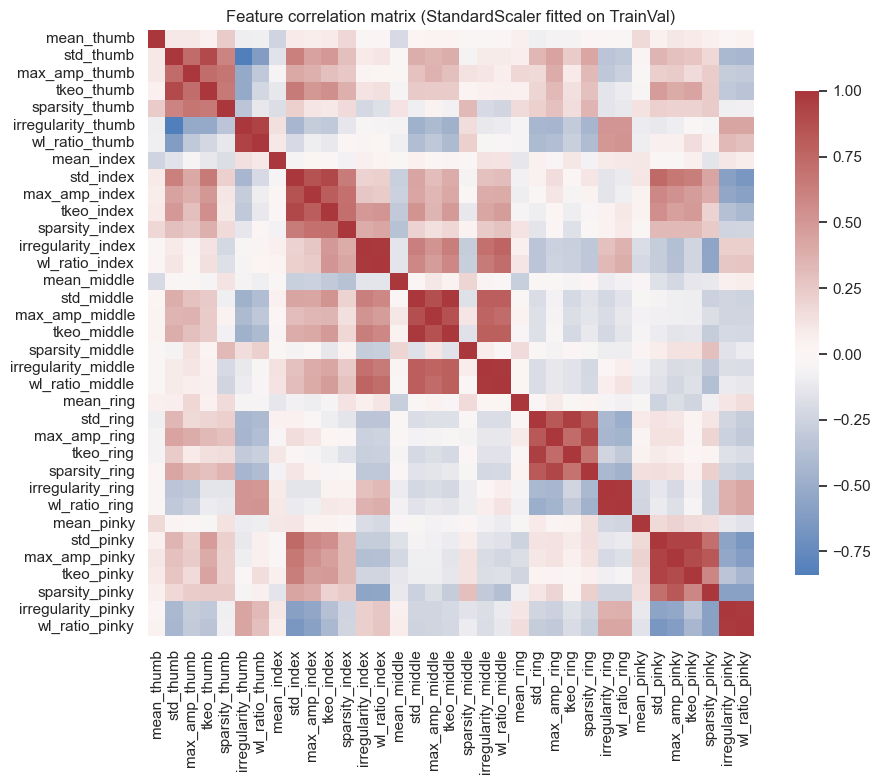

In [21]:
scaler_corr = StandardScaler()
X_trainval_scaled = scaler_corr.fit_transform(X_trainval)
df_trainval_scaled = pd.DataFrame(X_trainval_scaled, columns=feature_names)

corr = df_trainval_scaled.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="vlag", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature correlation matrix (StandardScaler fitted on TrainVal)")
plt.tight_layout()
plt.show()

## Regression: Gradient Boosting (Multi-output)

In [22]:
param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.005, 0.01, 0.02, 0.05, 0.1],
    "max_depth": [1, 2, 3, 4],
    "subsample": [0.6, 0.8, 1.0],
    "criterion": ['friedman_mse', 'squared_error'],
}

def build_model(params: dict) -> Pipeline:
    gbr = GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        criterion=params["criterion"],
    )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gbr", MultiOutputRegressor(gbr, n_jobs=-1)),
    ])

grid = list(ParameterGrid(param_grid))
print(f"Grid size: {len(grid)} candidates")

all_idx = np.arange(X_trainval.shape[0])

best_params: dict | None = None
best_cv_r2 = -np.inf
best_cv_r2_std = np.inf
best_cv_rmse = np.inf
best_cv_rmse_std = np.inf
t0 = time.time()

for k, params in enumerate(grid, start=1):
    fold_train_r2: list[float] = []
    fold_val_r2: list[float] = []
    fold_val_rmse: list[float] = []

    for val_idx in folds:
        train_idx = np.setdiff1d(all_idx, val_idx)
        X_tr, Y_tr = X_trainval[train_idx], Y_trainval[train_idx]
        X_va, Y_va = X_trainval[val_idx], Y_trainval[val_idx]

        model = build_model(params)
        model.fit(X_tr, Y_tr)
        Y_tr_pred = model.predict(X_tr)
        Y_va_pred = model.predict(X_va)

        fold_train_r2.append(float(r2_score(Y_tr, Y_tr_pred, multioutput="variance_weighted")))
        fold_val_r2.append(float(r2_score(Y_va, Y_va_pred, multioutput="variance_weighted")))
        fold_val_rmse.append(float(np.sqrt(mean_squared_error(Y_va, Y_va_pred))))

    cv_r2_mean = float(np.mean(fold_val_r2))
    cv_r2_std = float(np.std(fold_val_r2))
    cv_rmse_mean = float(np.mean(fold_val_rmse))
    cv_rmse_std = float(np.std(fold_val_rmse))
    tr_r2_mean = float(np.mean(fold_train_r2))

    if cv_r2_mean > best_cv_r2:
        best_cv_r2 = cv_r2_mean
        best_cv_r2_std = cv_r2_std
        best_cv_rmse = cv_rmse_mean
        best_cv_rmse_std = cv_rmse_std
        best_params = params

    elapsed = time.time() - t0
    print(
        f"[{k:>2}/{len(grid)}] train R^2={tr_r2_mean:+.3f} | CV val R^2={cv_r2_mean:+.3f}±{cv_r2_std:.3f} "
        f"| CV val RMSE={cv_rmse_mean:.3f}±{cv_rmse_std:.3f} | params={params}",
        flush=True,
    )

print("\nBest params (selected by mean CV val R^2):", best_params)
print(f"Best CV val R^2 (mean±std): {best_cv_r2:+.3f}±{best_cv_r2_std:.3f}")
print(f"Best CV val RMSE (mean±std): {best_cv_rmse:.3f}±{best_cv_rmse_std:.3f}")

final_model = build_model(best_params)
final_model.fit(X_trainval, Y_trainval)

Y_trainval_pred = final_model.predict(X_trainval)
r2_trainval = float(r2_score(Y_trainval, Y_trainval_pred, multioutput="variance_weighted"))
print(f"\nTRAINVAL R^2 (variance-weighted, final model): {r2_trainval:+.3f}")

Y_test_pred = final_model.predict(X_test)
r2_overall = float(r2_score(Y_test, Y_test_pred, multioutput="variance_weighted"))
rmse_overall = float(np.sqrt(mean_squared_error(Y_test, Y_test_pred)))
mae_overall = float(mean_absolute_error(Y_test, Y_test_pred))
print(f"TEST R^2 (variance-weighted): {r2_overall:+.3f}")
print(f"TEST RMSE (overall): {rmse_overall:.3f}")
print(f"TEST MAE  (overall): {mae_overall:.3f}")

Grid size: 480 candidates
[ 1/480] train R^2=+0.229 | CV val R^2=+0.190±0.016 | CV val RMSE=33.488±1.486 | params={'criterion': 'friedman_mse', 'learning_rate': 0.005, 'max_depth': 1, 'n_estimators': 50, 'subsample': 0.6}
[ 2/480] train R^2=+0.233 | CV val R^2=+0.194±0.022 | CV val RMSE=33.415±1.683 | params={'criterion': 'friedman_mse', 'learning_rate': 0.005, 'max_depth': 1, 'n_estimators': 50, 'subsample': 0.8}
[ 3/480] train R^2=+0.229 | CV val R^2=+0.184±0.027 | CV val RMSE=33.634±1.785 | params={'criterion': 'friedman_mse', 'learning_rate': 0.005, 'max_depth': 1, 'n_estimators': 50, 'subsample': 1.0}
[ 4/480] train R^2=+0.386 | CV val R^2=+0.321±0.028 | CV val RMSE=30.661±1.522 | params={'criterion': 'friedman_mse', 'learning_rate': 0.005, 'max_depth': 1, 'n_estimators': 100, 'subsample': 0.6}
[ 5/480] train R^2=+0.388 | CV val R^2=+0.323±0.029 | CV val RMSE=30.616±1.676 | params={'criterion': 'friedman_mse', 'learning_rate': 0.005, 'max_depth': 1, 'n_estimators': 100, 'subsample